In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ──────────────────────────────────────────────────────────────────────────
# Theoretical Risk Functions  (regression analogue of Cover & Hart 1967)
# ──────────────────────────────────────────────────────────────────────────

def ci_95(series):
    """
    95% confidence interval for the mean of a pandas Series or 1-D array,
    using the t-distribution (appropriate for small simulation counts).
    Returns (lower, upper).
    """
    from scipy.stats import t as t_dist
    n    = len(series)
    mean = np.mean(series)
    se   = np.std(series, ddof=1) / np.sqrt(n)
    h    = t_dist.ppf(0.975, df=n - 1) * se   # half-width
    return mean - h, mean + h

def compute_r_star_x(model, X_query, y_query):
    """
    Conditional risk r*(x) at each query point x for regression.

    r*(x) = (y_true - y_pred)^2  — squared residual per point.

    Parameters
    ----------
    model   : dict with 'dist_model' and 'prob_model' (KNeighborsRegressor GridSearchCV)
    X_query : query points  (n_samples × n_features)
    y_query : true target values  (n_samples,)

    Returns
    -------
    r_star : ndarray of shape (n_samples,)
    """
    prob_model = model['prob_model']
    y_pred = prob_model.predict(X_query)
    r_star = (np.asarray(y_query) - y_pred) ** 2
    return r_star


def compute_R_star(model, X_query, y_query):
    """
    Expected risk R* = E[r*(x)] — mean squared error over query points.

    Parameters
    ----------
    model   : dict with 'dist_model' and 'prob_model'
    X_query : held-out query points
    y_query : true targets

    Returns
    -------
    R_star : float
    """
    return float(compute_r_star_x(model, X_query, y_query).mean())


def compute_mu_hat(model, X):
    """
    Proxy for mu(x): the model's predicted value at each point (regression).

    Parameters
    ----------
    model : dict with 'prob_model' (KNeighborsRegressor GridSearchCV)
    X     : feature matrix

    Returns
    -------
    mu_hat : ndarray of shape (n_samples,)
    """
    prob_model = model['prob_model']
    return prob_model.predict(X)   # (n_samples,)


def compute_bias_vector(model, X_query, K_i):
    """
    Local bias for machine i (regression):
        Bi(x) = |mu(x) - (1/Ki) sum_j mu(xi,j)|

    Parameters
    ----------
    model   : dict with 'dist_model' and 'prob_model'
    X_query : query points  (n_samples x n_features)
    K_i     : number of neighbours used by this machine

    Returns
    -------
    B_i : ndarray of shape (n_samples,)
    """
    dist_model = model['dist_model']
    knn = dist_model.best_estimator_

    # mu(x) — predicted value at each query point
    mu_x = compute_mu_hat(model, X_query)   # (n_samples,)

    # Retrieve the K_i nearest training-set neighbours for each query point
    distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)

    # mu at every training point
    X_train_arr = knn._fit_X
    X_train_df  = pd.DataFrame(X_train_arr, columns=X_query.columns)
    mu_train    = compute_mu_hat(model, X_train_df)   # (n_train,)

    # Average mu over the K_i neighbours
    mu_neighbour_means = mu_train[indices].mean(axis=1)  # (n_samples,)

    B_i = np.abs(mu_x - mu_neighbour_means)  # (n_samples,)
    return B_i


print('Theoretical risk functions defined.')

Theoretical risk functions defined.


In [3]:
def create_models(server_datasets):

    best_neighbors = []
    best_mse_scores = []
    model_instance_list = []
    dataset_sizes = []

    for df_train, df_test in server_datasets:
        # Distance model: KNN for neighbor lookups
        params_knn = {"n_neighbors": np.arange(3, 51, 2)}
        knn = KNeighborsRegressor()
        dist_model = GridSearchCV(knn, params_knn, scoring='neg_mean_squared_error', cv=2, n_jobs=-1)

        # Probability model: Linear Regression for predictions
        prob_model = LinearRegression()

        X_s_train = df_train.drop(['y'], axis=1).values
        y_s_train = df_train['y'].values
        X_s_test  = df_test.drop(['y'], axis=1).values
        y_s_test  = df_test['y'].values

        # Fit both models
        dist_model.fit(X_s_train, y_s_train)
        prob_model.fit(X_s_train, y_s_train)
        
        y_pred = prob_model.predict(X_s_test)

        best_neighbors.append(dist_model.best_params_['n_neighbors'])
        best_mse_scores.append(mean_squared_error(y_s_test, y_pred))
        model_instance_list.append({
            'dist_model': dist_model,
            'prob_model': prob_model
        })

        dataset_sizes.append(df_train.shape[0])

    return (best_neighbors, best_mse_scores, model_instance_list, dataset_sizes)

In [4]:
class ModelPerformanceAnalyzer:
    def __init__(self, models, model_names=None):
        self.models = models
        self.model_names = model_names or [f"Model_{i}" for i in range(len(models))]
        self.performance_df = None

    def analyze_models(self, X_unseen, y_unseen):
        results = []
        for i, (model, name) in enumerate(zip(self.models, self.model_names)):
            model_metrics = self._analyze_single_model(model, name, i, X_unseen, y_unseen)
            results.append(model_metrics)
        self.performance_df = pd.DataFrame(results)
        return self.performance_df

    def _analyze_single_model(self, model, name, index, X_unseen, y_unseen):
        y_pred = model['prob_model'].predict(X_unseen)

        metrics = {
            'model_name': name,
            'model_index': index,
            'mse': mean_squared_error(y_unseen, y_pred),
            'r2': r2_score(y_unseen, y_pred),
            'predictions': y_pred.tolist()
        }

        distance_metrics = self._calculate_distance_metrics(model['dist_model'], X_unseen)
        metrics.update(distance_metrics)
        return metrics

    def _calculate_distance_metrics(self, model, X_unseen):
        """Calculate various distance-based metrics."""
        try:
            nbrs = model.best_estimator_
            distances, indices = nbrs.kneighbors(X_unseen)
            distances_no_self = distances

            point_medians = np.median(distances_no_self, axis=1)
            point_means   = np.mean(distances_no_self, axis=1)
            point_mins    = np.min(distances_no_self, axis=1)
            point_maxs    = np.max(distances_no_self, axis=1)

            return {
                'median_distance_all_points': np.median(point_medians),
                'mean_distance_all_points':   np.mean(point_means),
                'min_distance_all_points':    np.min(point_mins),
                'max_distance_all_points':    np.max(point_maxs),
                'distance_std':               np.std(distances_no_self),
            }
        except Exception as e:
            warnings.warn(f"Distance calculation failed for model: {e}")
            return {
                'median_distance_all_points': np.nan,
                'mean_distance_all_points':   np.nan,
                'min_distance_all_points':    np.nan,
                'max_distance_all_points':    np.nan,
                'distance_std':               np.nan,
            }

    def get_predictions_matrix(self, model_index):
        """Get predictions for a specific model as numpy array."""
        if self.performance_df is not None:
            return np.array(self.performance_df.loc[model_index, 'predictions'])
        return None

    def get_all_predictions(self):
        """Get all prediction arrays as a 2D array (models x samples)."""
        if self.performance_df is not None:
            return np.array([np.array(p) for p in self.performance_df['predictions']])
        return None

In [5]:
def run_distributed_knn_simulation(data_train, data_test, n_simulations=10, n_servers=100, test_size=0.2):
    """
    Distributed KNN Regressor simulation with query-dependent optimal weights W*(x_q).
    
    Implements per-query optimal weights based on per-query spatial bias c_i(x_q)
    and per-query risk r*_i(x_q), consistent with Sherman-Morrison-Woodbury formula.
    """
    import scipy.linalg as la

    simulation_results = []
    all_medians = []
    all_means   = []

    for sim in range(n_simulations):
        print(f"Running simulation {sim+1}/{n_simulations}")

        # 1. Split data
        X_train_full   = data_train.drop(['y'], axis=1)
        y_train_full   = data_train['y']
        X_test_heldout = data_test.drop(['y'], axis=1)
        y_test_heldout = data_test['y']

        # 2. Generate server datasets (use ShuffleSplit for regression — no stratification)
        # 2. Generate server datasets
        def generate_server_datasets(train_pool, test_pool, n_servers=100,
                                    min_samples=1000, max_samples=5000):
            """
            Plain random (non-stratified) sampling — each server gets a random
            subset of varying size, so class distributions will naturally vary
            across servers. This is the condition our distance-weighting is
            designed to handle.
            """
            server_datasets = []
            n_train_pool    = len(train_pool)
            n_test_pool     = len(test_pool)

            for seed in range(n_servers):
                rng = np.random.default_rng(seed)

                train_size   = rng.integers(min_samples, max_samples)
                train_idx    = rng.choice(n_train_pool, size=train_size, replace=False)
                server_train = train_pool.iloc[train_idx]

                test_size_s = int(0.3 * train_size)
                test_idx    = rng.choice(n_test_pool, size=test_size_s, replace=False)
                server_test = test_pool.iloc[test_idx]

                server_datasets.append((server_train, server_test))

            return server_datasets

        train_pool_df = pd.concat([X_train_full, y_train_full], axis=1)
        test_pool_df  = pd.concat([X_test_heldout, y_test_heldout], axis=1)

        min_samples = int(0.05 * len(train_pool_df))
        max_samples = int(0.4 * len(train_pool_df))

        server_datasets = generate_server_datasets(
            train_pool_df, test_pool_df, n_servers, min_samples, max_samples
        )

        # 3. Train models
        best_neighbors, best_mse_scores, model_instance_list, dataset_sizes = create_models(server_datasets)

        metrics_df = pd.DataFrame({
            'optimal_k_value': best_neighbors,
            'best_mse_scores': best_mse_scores,
            'model_instance':  model_instance_list,
            'dataset_size':    dataset_sizes
        })
        # Filter out degenerate models (infinite MSE)
        metrics_df = metrics_df[np.isfinite(metrics_df['best_mse_scores'])].reset_index(drop=True)

        # 4. Test on held-out data
        n_test_samples = min(500, len(X_test_heldout))
        test_indices   = np.random.choice(len(X_test_heldout), size=n_test_samples, replace=False)
        X_test_samples = X_test_heldout.iloc[test_indices]
        y_test_true    = y_test_heldout.iloc[test_indices]

        # Use ModelPerformanceAnalyzer to get all metrics and predictions
        analyzer    = ModelPerformanceAnalyzer(metrics_df['model_instance'].tolist())
        analysis_df = analyzer.analyze_models(X_test_samples, y_test_true)

        # Merge results
        metrics_df = metrics_df.merge(
            analysis_df[['model_index', 'median_distance_all_points', 'mean_distance_all_points']],
            left_index=True,
            right_on='model_index'
        ).reset_index(drop=True)

        all_medians.extend(metrics_df['median_distance_all_points'].tolist())
        all_means.extend(metrics_df['mean_distance_all_points'].tolist())

        # 5. Define scoring functions (unchanged — same aggregation method)
        def arctan_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + (np.arctan(((max_d + min_d)/2) - distance) / np.pi)

        def tanh_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + 0.5 * (np.tanh(((max_d + min_d)/2) - distance))

        def sigmoid_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 1 / (1 + 2 * np.exp(((max_d + min_d)/2) - distance))

        def relu_score(distance, df):
            mean      = df['mean_distance_all_points'].mean()
            deviation = df['mean_distance_all_points'].std()
            score     = mean + 2 * deviation - distance
            return score if score > 0 else 0

        metrics_df['arctan_score']  = metrics_df['median_distance_all_points'].apply(lambda x: arctan_score(x, metrics_df))
        metrics_df['tanh_score']    = metrics_df['median_distance_all_points'].apply(lambda x: tanh_score(x, metrics_df))
        metrics_df['sigmoid_score'] = metrics_df['median_distance_all_points'].apply(lambda x: sigmoid_score(x, metrics_df))
        metrics_df['relu_score']    = metrics_df['median_distance_all_points'].apply(lambda x: relu_score(x, metrics_df))

        # 6. Extract predictions from each model
        all_preds = analyzer.get_all_predictions()  # (M, n_query)

        # 7. Theoretical risk quantities for regression
        sim_models = metrics_df['model_instance'].tolist()
        sim_K_list = metrics_df['optimal_k_value'].tolist()
        M_sim      = len(sim_models)
        n_q        = len(X_test_samples)
        y_true_arr = np.asarray(y_test_true)

        def _r_star_x(model, X, y):
            """r*(x) = squared residual per point (regression)."""
            y_pred = model['prob_model'].predict(X)
            return (np.asarray(y) - y_pred) ** 2

        def _bias_scalar_gwls(model, X_query, K_i):
            """
            Query-dependent spatial bias c_i(x_q) using Gaussian-kernel Weighted Least Squares (GWLS).
            
            For each query point x_q, computes the spatial bias magnitude as:
                c_i(x_q) = |Θ_i(x_q) @ d_i(x_q)|
            
            where Θ_i is the gradient matrix (scalar for regression), and d_i is the median 
            displacement vector.
            
            This quantity is query-dependent, enabling per-query optimal weights that adapt 
            to local model accuracy r*_i(x_q) and local bias.

            Returns
            -------
            c_i : ndarray of shape (n_query,)  — one bias magnitude per query point per server
            """
            knn        = model['dist_model'].best_estimator_
            prob_model = model['prob_model']
            X_train    = knn._fit_X
            X_q_arr    = X_query.values

            X_train_df  = pd.DataFrame(X_train, columns=X_query.columns)
            p_train     = prob_model.predict(X_train_df)   # (n_train,) — regression predictions

            distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)

            c_scalars = []
            for q_idx in range(n_q):
                xq       = X_q_arr[q_idx]
                nbr_idx  = indices[q_idx]
                nbr_dist = distances[q_idx]

                X_nbr    = X_train[nbr_idx]
                p_nbr    = p_train[nbr_idx]   # (K_i,) regression targets

                X_mean   = X_nbr.mean(axis=0)
                p_mean   = p_nbr.mean()
                Xi_c     = X_nbr - X_mean
                yi_c     = p_nbr - p_mean

                # Gaussian kernel weights
                h        = np.median(nbr_dist) + 1e-8
                gk_w     = np.exp(-(nbr_dist ** 2) / (h ** 2))
                W_diag   = np.diag(gk_w)

                # WLS normal equations
                XtWX     = Xi_c.T @ W_diag @ Xi_c + 1e-6 * np.eye(Xi_c.shape[1])
                XtWy     = Xi_c.T @ (gk_w * yi_c)
                g_i      = np.linalg.solve(XtWX, XtWy)

                # Median displacement vector
                med_idx  = np.argmin(np.abs(nbr_dist - np.median(nbr_dist)))
                d_i      = X_nbr[med_idx] - xq

                # c_i(x_q) = |Θ_i @ d_i| — spatial bias magnitude at query q
                c_q = np.abs(float(g_i @ d_i))
                c_scalars.append(c_q)

            return np.array(c_scalars)  # (n_query,)

        # r*(x) and R* per server
        r_star_x_list, R_star_list = [], []
        for model in sim_models:
            r_x = _r_star_x(model, X_test_samples, y_test_true)
            r_star_x_list.append(r_x)
            R_star_list.append(float(r_x.mean()))

        r_star_matrix = np.stack(r_star_x_list, axis=0)   # (M, n_query) — per-server per-query risk
        R_star_vec    = np.array(R_star_list)             # (M,) — global per-server average

        # c_i(x_q) — per-query per-server spatial bias magnitudes
        # Shape: (M, n_query) — query-dependent for query-adaptive optimal weighting
        c_matrix = np.array([
            _bias_scalar_gwls(model, X_test_samples, K_i)
            for model, K_i in zip(sim_models, sim_K_list)
        ])  # (M, n_query)

        # For logging and reference: per-server scalar (mean across queries)
        b_vec = c_matrix.mean(axis=1)  # (M,) — mean c_i across all queries

        # C = b bᵀ — rank-1 outer product as defined for global reference
        C = np.outer(b_vec, b_vec)  # (M, M)

        # V diagonal: Vᵢᵢ = R*ᵢ / Kᵢ (global average)
        V = np.diag(R_star_vec / np.array(sim_K_list, dtype=float))

        # ── Per-query optimal W* via Sherman-Morrison ────────────────────────
        K_vec = np.array(sim_K_list, dtype=float)
        W_star_per_query = np.zeros((n_q, M_sim))   # (n_query, M)

        for q_idx in range(n_q):
            # Extract per-query quantities at this query point
            r_q     = np.clip(r_star_matrix[:, q_idx], 1e-8, None)  # (M,) per-server risk at x_q
            c_q     = c_matrix[:, q_idx]                            # (M,) per-server spatial bias at x_q
            V_inv_q = K_vec / r_q                   # diagonal of V⁻¹(x_q): [k_i / r*_i(x_q)]
            
            # Apply Sherman-Morrison formula: (V + cc^T)^{-1} = V^{-1} - V^{-1}cc^T V^{-1} / (1 + c^T V^{-1} c)
            S11_q   = np.sum(V_inv_q)                      # 1^T V^{-1}(x_q) 1
            Sb1_q   = float(c_q @ V_inv_q)               # c(x_q)^T V^{-1}(x_q) 1
            Sbb_q   = float(c_q @ (V_inv_q * c_q))       # c(x_q)^T V^{-1}(x_q) c(x_q)
            denom_q = S11_q - (Sb1_q ** 2) / (1.0 + Sbb_q)

            if abs(denom_q) < 1e-10:
                # Degenerate case: fall back to uniform weights
                W_star_per_query[q_idx] = 1.0 / M_sim
                continue

            # Optimal weight numerator: (V^{-1}(x_q))_i * (1 - c_i(x_q) S_c1(x_q) / (1 + S_cc(x_q)))
            num_q = V_inv_q * (1.0 - c_q * Sb1_q / (1.0 + Sbb_q))
            w_q   = num_q / denom_q
            w_q   = np.clip(w_q, 0.0, None)      # Non-negativity constraint
            w_q  /= w_q.sum()                     # Normalization: sum to 1
            W_star_per_query[q_idx] = w_q

        # Store representative W* for logging (mean across queries)
        W_star        = W_star_per_query.mean(axis=0)
        R_global_mean = float(R_star_vec.mean())
        R_optimal     = float('nan')  # Per-query optimal risk not computed in this variant

        B_matrix = c_matrix  # (M, n_query) — query-dependent spatial bias magnitudes

        # 8. Weighted predictions — approaches 1–5 (heuristic) + approach 6 (optimal W*)
        approaches = {
            'approach_1': 'arctan_score',
            'approach_2': 'dataset_size',
            'approach_3': 'tanh_score',
            'approach_4': 'sigmoid_score',
            'approach_5': 'relu_score'
        }

        approach_preds = {}
        for approach_name, weight_col in approaches.items():
            weights = metrics_df[weight_col].values.astype(float)
            w_sum   = weights.sum()
            if w_sum == 0:
                w_sum = 1.0
            # all_preds: (M, n_query) — weighted mean across models
            approach_preds[approach_name] = (all_preds * weights[:, None]).sum(axis=0) / w_sum

        # Approach 6 — per-query W*
        weighted_results_wstar = []
        for q_idx in range(n_q):
            w_q = W_star_per_query[q_idx]              # (M,) query-specific weights
            weighted_results_wstar.append((all_preds[:, q_idx] * w_q).sum())
        approach_preds['approach_6'] = np.array(weighted_results_wstar)

        # 9. Calculate MSE and R2 for all approaches
        sim_result = {'simulation': sim}
        for approach_name, preds in approach_preds.items():
            sim_result[f'{approach_name}_mse'] = mean_squared_error(y_test_true, preds)
            sim_result[f'{approach_name}_r2']  = r2_score(y_test_true, preds)

        sim_result.update({
            'n_servers':           len(metrics_df),
            'avg_dataset_size':    metrics_df['dataset_size'].mean(),
            'avg_median_distance': metrics_df['median_distance_all_points'].mean(),
            # Theoretical quantities
            'r_star_per_server':   R_star_list,
            'r_star_x_matrix':     r_star_matrix.tolist(),
            'bias_matrix':         B_matrix.tolist(),
            'c_matrix':            c_matrix.tolist(),
            'C_matrix':            C.tolist(),
            'V_diag':              np.diag(V).tolist(),
            'W_star':              W_star.tolist(),
            'mean_R_star':         R_global_mean,
            'min_R_star':          float(R_star_vec.min()),
            'max_R_star':          float(R_star_vec.max()),
            'optimal_R':           R_optimal,
        })

        simulation_results.append(sim_result)

    results_df = pd.DataFrame(simulation_results)
    return results_df, all_medians, all_means

In [6]:
# Load your data
# data_train = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/adult_preprocessed_train.csv')
# data_test = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/adult_preprocessed_test.csv')

data_train = pd.read_csv('../data/traffic_preprocessed_train.csv')
data_test  = pd.read_csv('../data/traffic_preprocessed_test.csv')

# Run multiple simulations
results_df, all_medians, all_means = run_distributed_knn_simulation(
    data_train, data_test, n_simulations=50, n_servers=10
)

Running simulation 1/50
Running simulation 2/50
Running simulation 3/50
Running simulation 4/50
Running simulation 5/50
Running simulation 6/50
Running simulation 7/50
Running simulation 8/50
Running simulation 9/50
Running simulation 10/50
Running simulation 11/50


KeyboardInterrupt: 

In [ ]:
# Find the best Linear Regression on overall data (with KNN for distances)
X_train = data_train.drop(['y'], axis=1)
y_train = data_train['y']
X_test  = data_test.drop(['y'], axis=1)
y_test  = data_test['y']

# Distance model: KNN
params_knn = {"n_neighbors": np.arange(3, 31, 2)}
knn = KNeighborsRegressor()
dist_model_global = GridSearchCV(knn, params_knn, scoring='neg_mean_squared_error', cv=2, n_jobs=-1)
dist_model_global.fit(X_train.values, y_train.values)

# Probability model: Linear Regression
prob_model_global = LinearRegression()
prob_model_global.fit(X_train.values, y_train.values)

y_pred = prob_model_global.predict(X_test.values)

buffer_model = {"dist_model": dist_model_global, "prob_model": prob_model_global}

R_star_global_model = compute_R_star(buffer_model, X_test, y_test)
k_global_model      = dist_model_global.best_params_['n_neighbors']
V_global_model      = R_star_global_model / k_global_model

benchmark_mse = mean_squared_error(y_test, y_pred)
benchmark_r2  = r2_score(y_test, y_pred)
benchmark_mae = mean_absolute_error(y_test, y_pred)

print(f"KNN Best Params: {dist_model_global.best_params_}")
print(f"Linear Regression - No hyperparameters to tune")
print(f"Benchmark MSE:  {benchmark_mse:.4f}")
print(f"Benchmark MAE:  {benchmark_mae:.4f}")
print(f"Benchmark R²:   {benchmark_r2:.4f}")

KNN Best Params: {'n_neighbors': np.int64(5)}
Linear Regression - No hyperparameters to tune
Benchmark MSE:  1.2794
Benchmark MAE:  0.8164
Benchmark R²:   0.9777


In [ ]:
print("Simulation Results Summary")
print("=" * 80)
print(f"Number of simulations: {len(results_df)}")

approaches_labels = {
    'approach_1': 'Arctan ',
    'approach_2': 'Size   ',
    'approach_3': 'Tanh   ',
    'approach_4': 'Sigmoid',
    'approach_5': 'ReLU   ',
    'approach_6': 'W*     ',
}

metrics_info = [
    ('MSE', '_mse', True),   # lower is better
    ('R²',  '_r2',  False),  # higher is better
]

print()
for metric_name, suffix, lower_better in metrics_info:
    direction = '(↓ better)' if lower_better else '(↑ better)'
    print(f"Average {metric_name} {direction}:")
    print(f"  {'Approach':<10} {'Mean':>8}  {'Std':>8}  {'95% CI':>22}")
    print(f"  {'-'*10}  {'-'*8}  {'-'*8}  {'-'*22}")
    for key, label in approaches_labels.items():
        col       = f'{key}{suffix}'
        vals      = results_df[col].dropna()
        mean      = vals.mean()
        std       = vals.std()
        lo, hi    = ci_95(vals)
        print(f"  {label:<10} {mean:>8.4f}  {std:>8.4f}  [{lo:>8.4f}, {hi:>8.4f}]")

print(f"\nBenchmark (global KNN Regressor) — MSE: {benchmark_mse:.4f}, R²: {benchmark_r2:.4f}")

Simulation Results Summary
Number of simulations: 50

Average MSE (↓ better):
  Approach       Mean       Std                  95% CI
  ----------  --------  --------  ----------------------
  Arctan       1.2493    0.1518  [  1.2062,   1.2925]
  Size         1.2504    0.1531  [  1.2069,   1.2939]
  Tanh         1.2493    0.1518  [  1.2061,   1.2924]
  Sigmoid      1.2495    0.1515  [  1.2064,   1.2926]
  ReLU         1.2489    0.1525  [  1.2056,   1.2923]
  W*           1.2019    0.1521  [  1.1587,   1.2452]
Average R² (↑ better):
  Approach       Mean       Std                  95% CI
  ----------  --------  --------  ----------------------
  Arctan       0.9782    0.0018  [  0.9777,   0.9788]
  Size         0.9782    0.0018  [  0.9777,   0.9787]
  Tanh         0.9782    0.0018  [  0.9777,   0.9788]
  Sigmoid      0.9782    0.0018  [  0.9777,   0.9788]
  ReLU         0.9782    0.0018  [  0.9777,   0.9788]
  W*           0.9791    0.0018  [  0.9785,   0.9796]

Benchmark (global KNN Re

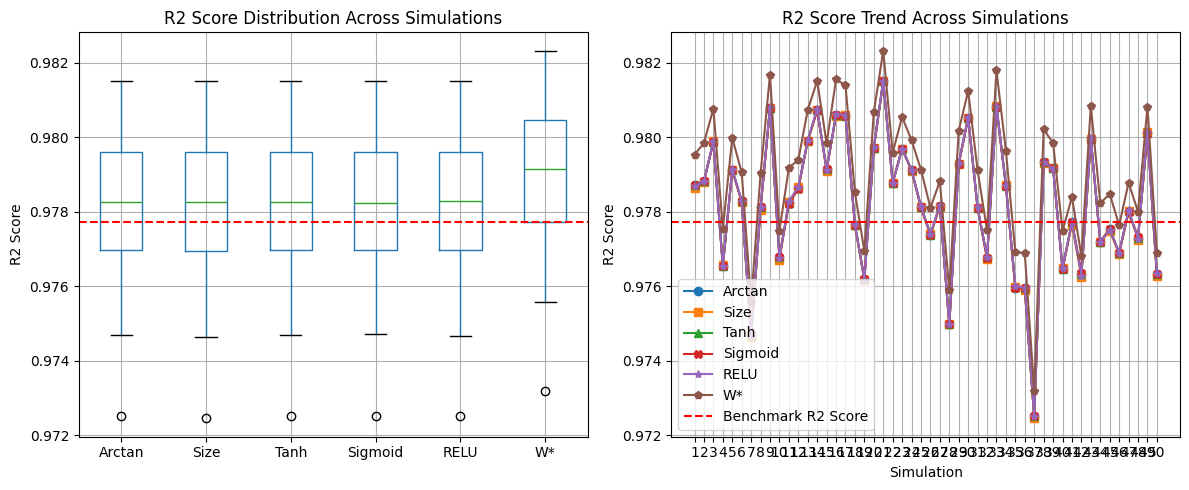

In [ ]:
# %%
# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
results_df[['approach_1_r2', 'approach_2_r2', 'approach_3_r2', 'approach_4_r2', 'approach_5_r2', 'approach_6_r2']].boxplot()
plt.title('R2 Score Distribution Across Simulations')
plt.ylabel('R2 Score')
plt.axhline(y=benchmark_r2, color='r', linestyle='--', label='Benchmark R2 Score')
plt.xticks([1, 2, 3, 4, 5, 6], ['Arctan', 'Size', 'Tanh', 'Sigmoid', 'RELU', 'W*'])

plt.subplot(1, 2, 2)
plt.plot(results_df['approach_1_r2'], label='Arctan', marker='o')
plt.plot(results_df['approach_2_r2'], label='Size', marker='s')
plt.plot(results_df['approach_3_r2'], label='Tanh', marker='^')
plt.plot(results_df['approach_4_r2'], label='Sigmoid', marker='X')
plt.plot(results_df['approach_5_r2'], label='RELU', marker='*')
plt.plot(results_df['approach_6_r2'], label='W*', marker='p')
plt.axhline(y=benchmark_r2, color='r', linestyle='--', label='Benchmark R2 Score')
plt.xticks(np.arange(len(results_df)), np.arange(1, len(results_df)+1))
plt.xlabel('Simulation')
plt.ylabel('R2 Score')
plt.title('R2 Score Trend Across Simulations')
plt.legend()
plt.grid(True)

# plt.savefig('f1_score_trends_std_normal.png')

plt.tight_layout()
plt.show()


In [ ]:
# %%
# Statistical significance testing
from scipy.stats import ttest_rel

# ── Pairwise MSE t-tests ──────────────────────────────────────────────────────
pairs = [
    ('Arctan',  'approach_1', 'Size',    'approach_2'),
    ('Arctan',  'approach_1', 'Tanh',    'approach_3'),
    ('Size',    'approach_2', 'Tanh',    'approach_3'),
    ('Size',    'approach_2', 'Sigmoid', 'approach_4'),
    ('Tanh',    'approach_3', 'Sigmoid', 'approach_4'),
    ('Arctan',  'approach_1', 'Sigmoid', 'approach_4'),
]

print("Pairwise t-tests (MSE — lower is better):")
print(f"  {'Comparison':<22} {'p-value':>8}  {'95% CI on Δ':>26}")
print(f"  {'-'*22}  {'-'*8}  {'-'*26}")
for lA, kA, lB, kB in pairs:
    diff     = results_df[f'{kA}_mse'] - results_df[f'{kB}_mse']
    t, p     = ttest_rel(results_df[f'{kA}_mse'], results_df[f'{kB}_mse'])
    lo, hi   = ci_95(diff)
    label    = f'{lA} vs {lB}'
    print(f"  {label:<22} {p:>8.4f}  [{lo:>+9.4f}, {hi:>+9.4f}]")

# ── W* vs ReLU equivalence ────────────────────────────────────────────────────
print("\n── W* vs ReLU equivalence (paired t-test, two-tailed, α=0.05) ──")
print(f"{'Metric':<8} {'t-stat':>8}  {'p-value':>8}  {'Mean Δ':>9}  {'95% CI on Δ':>26}  {'Verdict'}")
print("-" * 80)
alpha = 0.05

# MSE test (lower is better, so negative mean Δ is good)
diff_mse = results_df['approach_6_mse'] - results_df['approach_5_mse']
t_mse, p_mse = ttest_rel(results_df['approach_6_mse'], results_df['approach_5_mse'])
lo_mse, hi_mse = ci_95(diff_mse)
equiv_mse = p_mse > alpha
verdict_mse = 'equivalent' if equiv_mse else 'DIFFERENT'
print(f"{'MSE':<8} {t_mse:>8.4f}  {p_mse:>8.4f}  {diff_mse.mean():>+9.4f}  [{lo_mse:>+9.4f}, {hi_mse:>+9.4f}]  {verdict_mse}")

# R² test (higher is better, so positive mean Δ is good)
diff_r2 = results_df['approach_6_r2'] - results_df['approach_5_r2']
t_r2, p_r2 = ttest_rel(results_df['approach_6_r2'], results_df['approach_5_r2'])
lo_r2, hi_r2 = ci_95(diff_r2)
equiv_r2 = p_r2 > alpha
verdict_r2 = 'equivalent' if equiv_r2 else 'DIFFERENT'
print(f"{'R²':<8} {t_r2:>8.4f}  {p_r2:>8.4f}  {diff_r2.mean():>+9.4f}  [{lo_r2:>+9.4f}, {hi_r2:>+9.4f}]  {verdict_r2}")

print()
if equiv_mse and equiv_r2:
    print("→ W* is statistically as good as ReLU on ALL metrics.")
else:
    print("→ W* and ReLU differ significantly on at least one metric.")

Pairwise t-tests (MSE — lower is better):
  Comparison              p-value                 95% CI on Δ
  ----------------------  --------  --------------------------
  Arctan vs Size           0.0001  [  -0.0016,   -0.0006]
  Arctan vs Tanh           0.0119  [  +0.0000,   +0.0001]
  Size vs Tanh             0.0000  [  +0.0006,   +0.0016]
  Size vs Sigmoid          0.0048  [  +0.0003,   +0.0015]
  Tanh vs Sigmoid          0.0067  [  -0.0004,   -0.0001]
  Arctan vs Sigmoid        0.0058  [  -0.0003,   -0.0001]

── W* vs ReLU equivalence (paired t-test, two-tailed, α=0.05) ──
Metric     t-stat   p-value     Mean Δ                 95% CI on Δ  Verdict
--------------------------------------------------------------------------------
MSE      -47.9394    0.0000    -0.0470  [  -0.0490,   -0.0450]  DIFFERENT
R²        47.5759    0.0000    +0.0008  [  +0.0008,   +0.0009]  DIFFERENT

→ W* and ReLU differ significantly on at least one metric.
